In [1]:
import torch

from torch import nn
from torch import optim
from torch.utils.data import DataLoader

from torchvision.models import resnet18

import matplotlib.pyplot as plt

from utils.dataset import BaseImageFolderDataset
from utils.transforms import base_transforms, train_transforms
from utils.metrics import accuracy
from utils.trainer import train

In [2]:
GPU = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
SEED = 42

TRAIN_FRACTION = 0.01
LEARNING_RATE = 1e-4
BATCH_SIZE = 16

In [3]:
# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch CUDA
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# PyTorch backend determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
def plot_training_metrics(metrics_dict):
    """
    Plot training and validation metrics from a dictionary.

    Args:
        metrics_dict: Dictionary containing lists of metrics for each epoch
                      Expected keys: 'train_loss', 'train_acc1', 'train_acc5',
                                   'val_loss', 'val_acc1', 'val_acc5'
    """
    epochs = range(1, len(metrics_dict['train_loss']) + 1)

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Loss curves
    ax1.plot(epochs, metrics_dict['train_loss'],
             'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, metrics_dict['val_loss'],
             'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Accuracy curves (Top-1 and Top-5)
    ax2.plot(epochs, metrics_dict['train_acc1'],
             'b-', label='Train Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['val_acc1'],
             'r-', label='Val Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['train_acc5'], 'b--',
             label='Train Top-5', linewidth=2, alpha=0.7)
    ax2.plot(epochs, metrics_dict['val_acc5'], 'r--',
             label='Val Top-5', linewidth=2, alpha=0.7)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [5]:
class VisDA2017Train(BaseImageFolderDataset):
    URL = 'http://csr.bu.edu/ftp/visda17/clf/train.tar'
    ARCHIVE_NAME = 'train.tar'
    EXTRACTED_FOLDER = 'train'

class VisDA2017Validation(BaseImageFolderDataset):
    URL = ' http://csr.bu.edu/ftp/visda17/clf/validation.tar'
    ARCHIVE_NAME = 'validation.tar'
    EXTRACTED_FOLDER = 'validation'

In [6]:
train_dataset = VisDA2017Train(
    './data', transform=train_transforms, download=True
)

val_dataset = VisDA2017Validation(
    './data', transform=base_transforms, download=True
)

In [7]:
len(train_dataset), len(val_dataset)

(152397, 55388)

In [8]:
# TODO: Delete after tesing utils

import numpy as np
from torch.utils.data import Subset

np.random.seed(42)

# Generate random indices for split
train_indices = np.arange(len(train_dataset))
val_indices = np.arange(len(val_dataset))

np.random.shuffle(train_indices)
np.random.shuffle(val_indices)

train_size = int(len(train_dataset) * TRAIN_FRACTION)
val_size = int(len(val_dataset) * TRAIN_FRACTION)

train_indices = list(train_indices[:train_size])
val_indices = list(val_indices[:val_size])

train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)

In [9]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4
)

In [10]:
model = resnet18(num_classes=12)

In [11]:
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [12]:
loss = nn.CrossEntropyLoss()

In [13]:
from torch.utils.tensorboard import SummaryWriter

metrics = train(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    loss,
    accuracy,
    epochs=10,
    # start_epoch=2,
    checkpoint_interval=2,
    checkpoint_path='.',
    device=GPU,
    summary_writer=SummaryWriter(log_dir='./logs/resnet_pretrain')
)

Epoch   1 | Train Loss: 2.2748 | Train acc1: 20.2474 | Train acc5: 67.3828 | Val Loss: 3.4684 | Val acc1: 15.4960 | Val acc5: 50.3770


Epoch   2 | Train Loss: 2.0332 | Train acc1: 27.3655 | Train acc5: 81.2283 | Val Loss: 5.2819 | Val acc1: 21.2698 | Val acc5: 61.1508
Saving checkpoint...OK


Epoch   3 | Train Loss: 1.8721 | Train acc1: 30.9896 | Train acc5: 84.8958 | Val Loss: 4.1175 | Val acc1: 19.5635 | Val acc5: 63.7302


Epoch   4 | Train Loss: 1.8083 | Train acc1: 35.4384 | Train acc5: 83.6372 | Val Loss: 5.0918 | Val acc1: 26.4881 | Val acc5: 61.9048
Saving checkpoint...OK


Epoch   5 | Train Loss: 1.7613 | Train acc1: 39.3229 | Train acc5: 85.5035 | Val Loss: 4.3376 | Val acc1: 22.5198 | Val acc5: 63.8690


Epoch   6 | Train Loss: 1.6710 | Train acc1: 40.1693 | Train acc5: 87.8255 | Val Loss: 4.7743 | Val acc1: 22.3810 | Val acc5: 61.5079
Saving checkpoint...OK


Epoch   7 | Train Loss: 1.5774 | Train acc1: 44.6615 | Train acc5: 89.9089 | Val Loss: 4.8267 | Val acc1: 23.0556 | Val acc5: 59.8016


Epoch   8 | Train Loss: 1.5418 | Train acc1: 47.7648 | Train acc5: 88.4766 | Val Loss: 4.8171 | Val acc1: 20.4167 | Val acc5: 61.3294
Saving checkpoint...OK


Epoch   9 | Train Loss: 1.5078 | Train acc1: 48.3073 | Train acc5: 90.1042 | Val Loss: 4.1009 | Val acc1: 23.1349 | Val acc5: 61.5079


Epoch  10 | Train Loss: 1.4523 | Train acc1: 50.0651 | Train acc5: 90.2995 | Val Loss: 4.3199 | Val acc1: 23.4127 | Val acc5: 62.4405
Saving checkpoint...OK


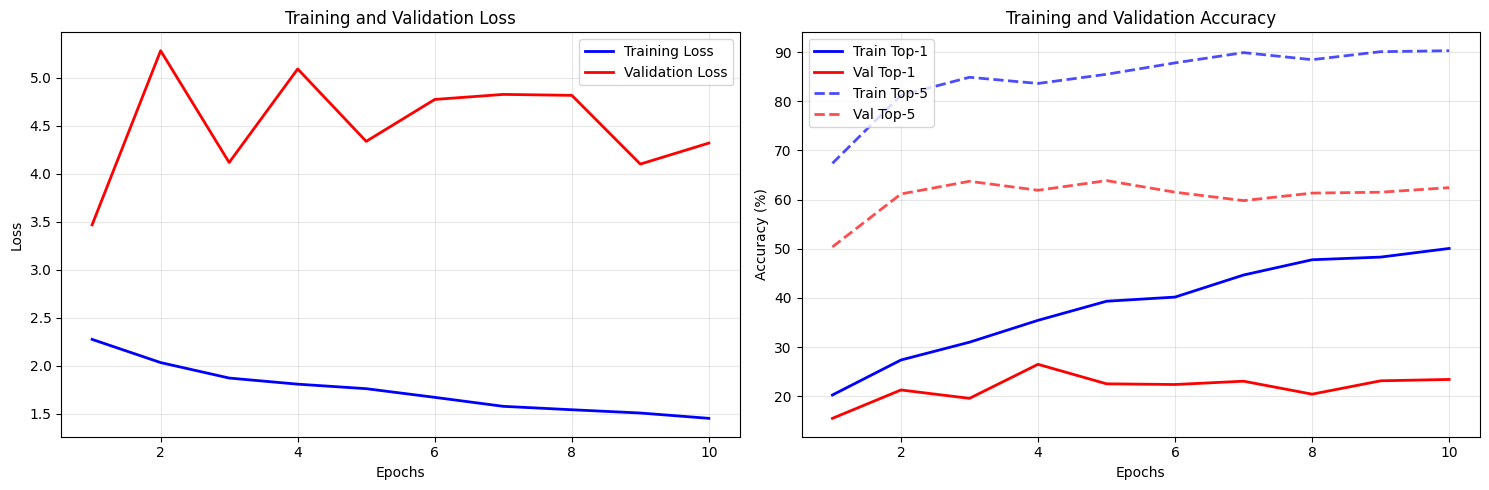

In [14]:
plot_training_metrics(metrics)